In [ ]:
# Main code containing Fine-Tuning for DDPM with Linear Noise Schedule, Correlation study, Synthetic Image Generation, FID Score calculation

# ── Safe remount — always run this first ─────────────────────────────
import os, shutil, subprocess
from google.colab import drive

subprocess.run(['fusermount', '-uz', '/content/drive'], capture_output=True)
shutil.rmtree('/content/drive', ignore_errors=True)
os.makedirs('/content/drive', exist_ok=True)

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
 # ──── Imports and path ────────────────────────────────────────

DATA_DIR       = '/content/drive/MyDrive/Dissertation2026/oasis-coronal-alzheimers' # dataset folder
files = [f for f in os.listdir(DATA_DIR) if f.endswith('.png')]
print(f"Found {len(files)} images")
print(f"Sample: {files[:3]}")

!pip install diffusers accelerate torchvision -q
import os
import torch
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from diffusers import DDPMPipeline, DDPMScheduler
from diffusers.optimization import get_cosine_schedule_with_warmup
from torchvision import transforms
import matplotlib.pyplot as plt

DATA_DIR       = '/content/drive/MyDrive/Dissertation2026/oasis-coronal-alzheimers'
OUTPUT_DIR     = '/content/drive/MyDrive/Dissertation2026/ddpm-coronal-v7_output'        # new output folder
CHECKPOINT_DIR = '/content/drive/MyDrive/Dissertation2026/ddpm-coronal-v7_checkpoints'

Found 700 images
Sample: ['OAS1_0003_MR1_coronal_anterior_hippocampal_idx095.png', 'OAS1_0003_MR1_coronal_anterior_hippocampal_idx110.png', 'OAS1_0003_MR1_coronal_anterior_hippocampal_idx098.png']


Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device : cuda
GPU    : Tesla T4
Loaded 700 images
Steps per epoch : 88
Total steps     : 6160

Loading pretrained brain MRI DDPM...


model_index.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]


Starting training (Run 2 — with augmentation)...

Epoch 001/70 | Loss: 0.017833
Epoch 002/70 | Loss: 0.022179
Epoch 003/70 | Loss: 0.015723
Epoch 004/70 | Loss: 0.016525
Epoch 005/70 | Loss: 0.016008
Epoch 006/70 | Loss: 0.014098
Epoch 007/70 | Loss: 0.014001
Epoch 008/70 | Loss: 0.014438
Epoch 009/70 | Loss: 0.014474
Epoch 010/70 | Loss: 0.014340


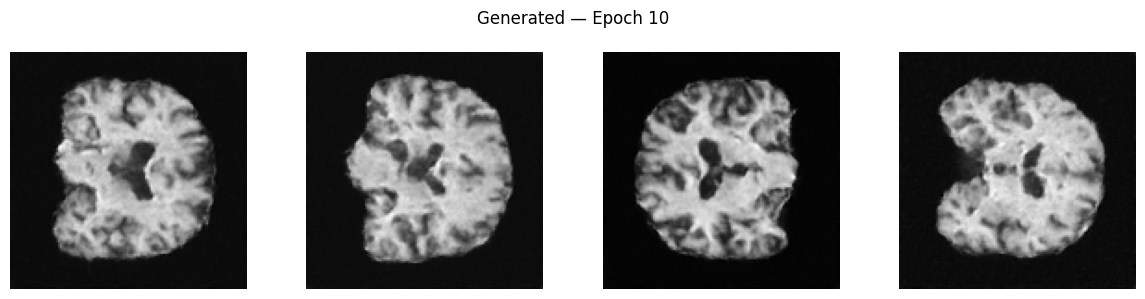

Epoch 011/70 | Loss: 0.012440
Epoch 012/70 | Loss: 0.014668
Epoch 013/70 | Loss: 0.014430
Epoch 014/70 | Loss: 0.015266
Epoch 015/70 | Loss: 0.015512
Epoch 016/70 | Loss: 0.011388
Epoch 017/70 | Loss: 0.012505
Epoch 018/70 | Loss: 0.011917
Epoch 019/70 | Loss: 0.010852
Epoch 020/70 | Loss: 0.014642


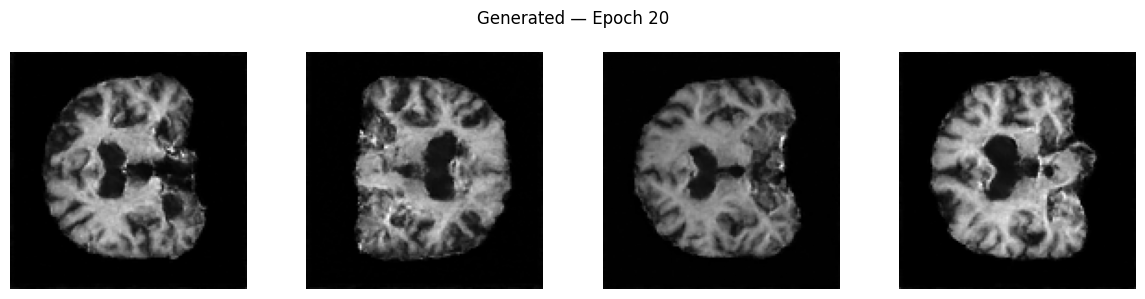

Epoch 021/70 | Loss: 0.011697
Epoch 022/70 | Loss: 0.013896
Epoch 023/70 | Loss: 0.012486
Epoch 024/70 | Loss: 0.012350
Epoch 025/70 | Loss: 0.012353
Epoch 026/70 | Loss: 0.015561
Epoch 027/70 | Loss: 0.012227
Epoch 028/70 | Loss: 0.013863
Epoch 029/70 | Loss: 0.011569
Epoch 030/70 | Loss: 0.012210


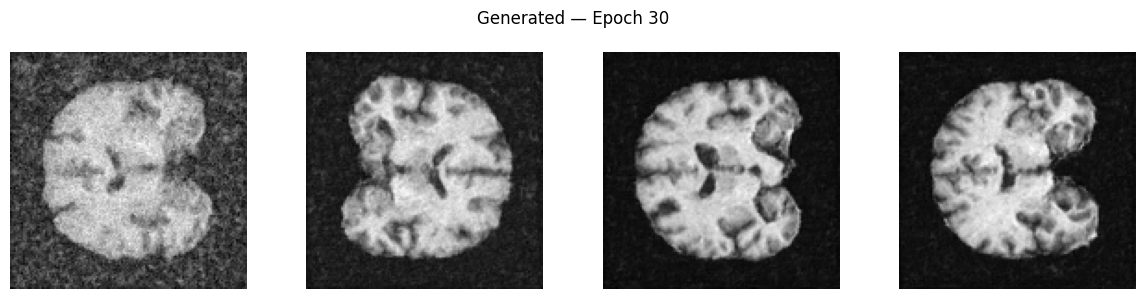

Epoch 031/70 | Loss: 0.012071
Epoch 032/70 | Loss: 0.013049
Epoch 033/70 | Loss: 0.014203
Epoch 034/70 | Loss: 0.011248
Epoch 035/70 | Loss: 0.012185
Epoch 036/70 | Loss: 0.013173
Epoch 037/70 | Loss: 0.012454
Epoch 038/70 | Loss: 0.012554
Epoch 039/70 | Loss: 0.010980
Epoch 040/70 | Loss: 0.011226


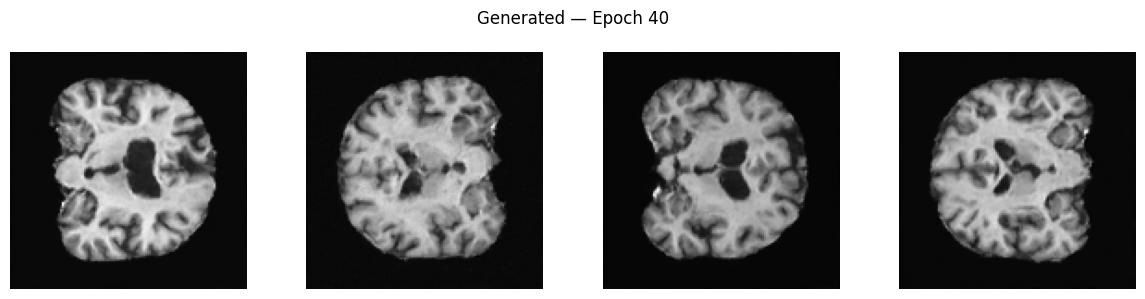

Epoch 041/70 | Loss: 0.011303
Epoch 042/70 | Loss: 0.011507
Epoch 043/70 | Loss: 0.011659
Epoch 044/70 | Loss: 0.013583
Epoch 045/70 | Loss: 0.014156
Epoch 046/70 | Loss: 0.011387
Epoch 047/70 | Loss: 0.011288
Epoch 048/70 | Loss: 0.011827
Epoch 049/70 | Loss: 0.011432
Epoch 050/70 | Loss: 0.011156


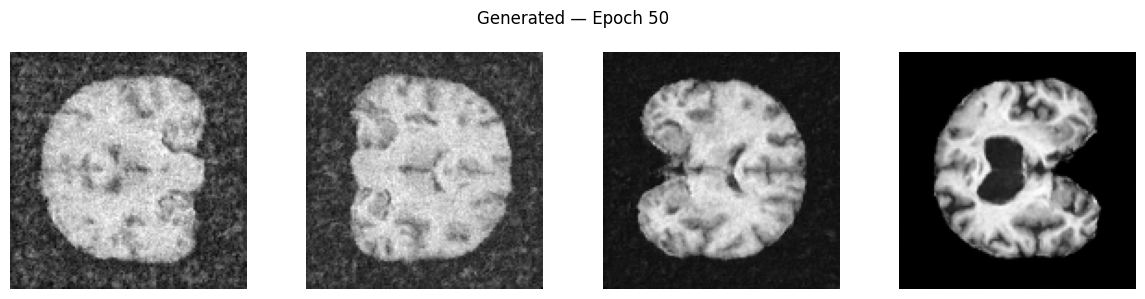

Epoch 051/70 | Loss: 0.011848
Epoch 052/70 | Loss: 0.010344
Epoch 053/70 | Loss: 0.010636
Epoch 054/70 | Loss: 0.013013
Epoch 055/70 | Loss: 0.009922
Epoch 056/70 | Loss: 0.009845
Epoch 057/70 | Loss: 0.011018
Epoch 058/70 | Loss: 0.009367
Epoch 059/70 | Loss: 0.012676
Epoch 060/70 | Loss: 0.012169


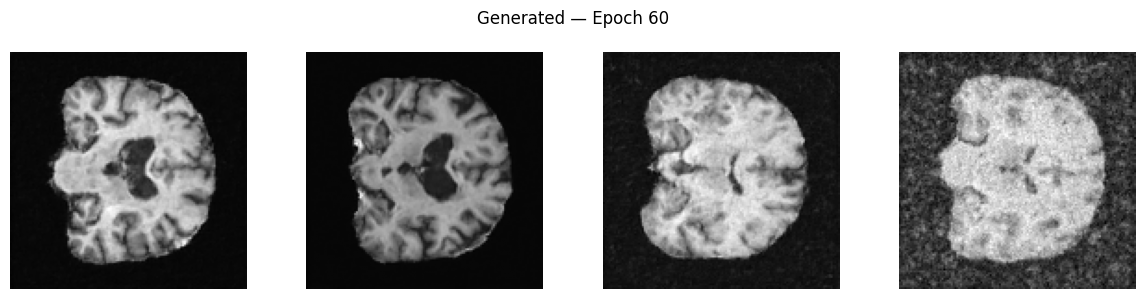

Epoch 061/70 | Loss: 0.013023
Epoch 062/70 | Loss: 0.009786
Epoch 063/70 | Loss: 0.011353
Epoch 064/70 | Loss: 0.011501
Epoch 065/70 | Loss: 0.010494
Epoch 066/70 | Loss: 0.010713
Epoch 067/70 | Loss: 0.010717
Epoch 068/70 | Loss: 0.011111
Epoch 069/70 | Loss: 0.010841
Epoch 070/70 | Loss: 0.012014
  ✅ Checkpoint saved → /content/drive/MyDrive/Dissertation2026/ddpm-coronal-v7_checkpoints/epoch_070


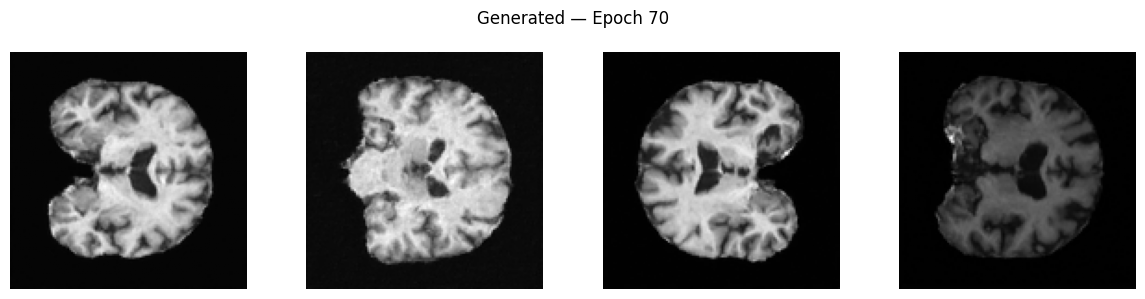


✅ Run 2 training complete!


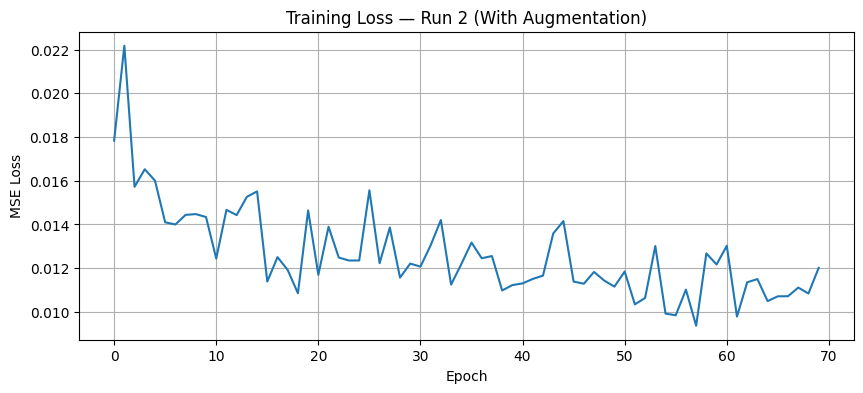

In [ ]:
### DDPM MODEL TRAINING (linear)
# ── Config ───────────────────────────────────────────────
IMAGE_SIZE    = 128
BATCH_SIZE    = 8
NUM_EPOCHS    = 70        # increased from 50 — augmented data converges slower
LEARNING_RATE = 1e-4
SAVE_EVERY    = 70
NUM_TIMESTEPS = 1000

os.makedirs(OUTPUT_DIR,     exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
print(f"GPU    : {torch.cuda.get_device_name(0)}")

# ── Dataset with AUGMENTATION ──────────────────────────── # Augmentation suggested by Gemini to improve model learning structural patches of brain
class MRIDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir   = img_dir
        self.files     = [f for f in os.listdir(img_dir) if f.endswith('.png')]
        self.transform = transform
        print(f"Loaded {len(self.files)} images")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.img_dir, self.files[idx])).convert('L')
        if self.transform:
            img = self.transform(img)
        return img

# ── Augmentation including random Rotation and Flips ───────────────────────
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),    # anatomically valid — brain is bilaterally symmetric
    transforms.RandomRotation(degrees=5, fill=0),       # small, realistic variation only
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

dataset    = MRIDataset(DATA_DIR, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

steps_per_epoch = len(dataloader)
total_steps     = steps_per_epoch * NUM_EPOCHS
print(f"Steps per epoch : {steps_per_epoch}")
print(f"Total steps     : {total_steps}")

# ── Load pretrained model from HugginFace [benetraco/brain_ddpm_128] ──
print("\nLoading pretrained brain MRI DDPM...")
pipeline  = DDPMPipeline.from_pretrained("benetraco/brain_ddpm_128")
model     = pipeline.unet.to(device)
scheduler = DDPMScheduler(
    num_train_timesteps=NUM_TIMESTEPS,
    beta_schedule="linear",
    beta_start=0.0001,
    beta_end=0.02,
)

# ── Optimizer ────────────────────────────────────────────
optimizer    = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer, num_warmup_steps=100, num_training_steps=total_steps,
)
scaler = torch.amp.GradScaler('cuda')

# ── Training loop ────────────────────────────────────────
print("\nStarting training (Run 2 — with augmentation)...\n")
loss_history = []

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0

    for batch in dataloader:
        images    = batch.to(device)
        timesteps = torch.randint(0, NUM_TIMESTEPS, (images.shape[0],), device=device).long()
        noise     = torch.randn_like(images)
        noisy     = scheduler.add_noise(images, noise, timesteps)

        with torch.amp.autocast('cuda'):
            pred = model(noisy, timesteps).sample
            loss = torch.nn.functional.mse_loss(pred, noise)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        lr_scheduler.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1:03d}/{NUM_EPOCHS} | Loss: {avg_loss:.6f}")
# ─── Saving at every 70 epoch────────────
    if (epoch + 1) % SAVE_EVERY == 0:
        ckpt_path = os.path.join(CHECKPOINT_DIR, f'epoch_{epoch+1:03d}')
        pipeline.unet = model
        pipeline.save_pretrained(ckpt_path)
        print(f"  ✅ Checkpoint saved → {ckpt_path}")
# ─── Preview 4 samples at every 10 epochs────────────
    if (epoch + 1) % 10 == 0:
        model.eval()
        with torch.no_grad():
            sample = torch.randn(4, 1, IMAGE_SIZE, IMAGE_SIZE).to(device)
            for t in scheduler.timesteps:
                with torch.amp.autocast('cuda'):
                    pred = model(sample, t).sample
                sample = scheduler.step(pred, t, sample).prev_sample
            sample = (sample.clamp(-1, 1) + 1) / 2
            fig, axes = plt.subplots(1, 4, figsize=(12, 3))
            fig.suptitle(f'Generated — Epoch {epoch+1}')
            for i in range(4):
                axes[i].imshow(sample[i, 0].cpu().numpy(), cmap='gray')
                axes[i].axis('off')
            plt.tight_layout()
            plt.savefig(f'{OUTPUT_DIR}/samples_epoch_{epoch+1:03d}.png')
            plt.show()

# ── Save final model to Drive ─────────────────────────────────────
pipeline.unet = model
pipeline.save_pretrained(f'{OUTPUT_DIR}/final_model')
print("\n✅ Run 2 training complete!")
# Training loss plot
plt.figure(figsize=(10, 4))
plt.plot(loss_history)
plt.title('Training Loss — Run 2 (With Augmentation)')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss'); plt.grid(True)
plt.savefig(f'{OUTPUT_DIR}/loss_curve.png')
plt.show()

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

Generating synthetic Alzheimer's coronal MRI slices...


  0%|          | 0/1000 [00:00<?, ?it/s]

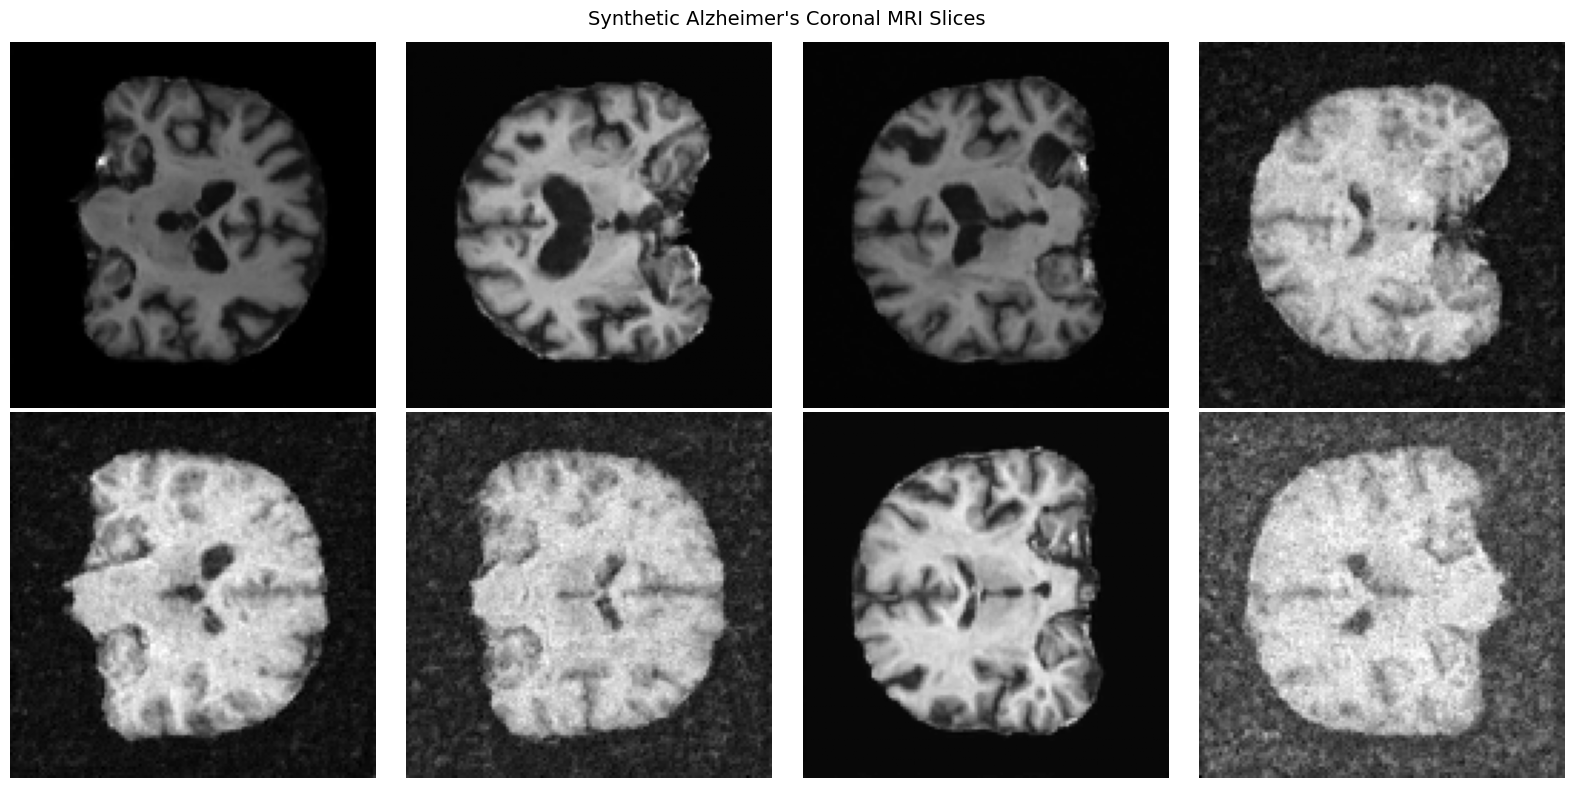

In [ ]:
# ────Generating SAMPLE synthetic images from the trained model ────────────────────────────────────────

import torch
import matplotlib.pyplot as plt
from diffusers import DDPMPipeline, DDPMScheduler

# Load your fine-tuned model
MODEL_PATH = '/content/drive/MyDrive/Dissertation2026/ddpm-coronal-v7_output/final_model'

pipeline = DDPMPipeline.from_pretrained(MODEL_PATH).to('cuda')

# Generate 8 synthetic images
print("Generating synthetic Alzheimer's coronal MRI slices...")
with torch.no_grad():
    images = pipeline(batch_size=8, num_inference_steps=1000).images

# Display them
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Synthetic Alzheimer\'s Coronal MRI Slices', fontsize=14)
for i, img in enumerate(images):
    row, col = i // 4, i % 4
    axes[row, col].imshow(img, cmap='gray')
    axes[row, col].axis('off')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Dissertation2026/ddpm-coronal-v7_output/final_samples.png')
plt.show()

Loading model...


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

Generating synthetic Alzheimer's coronal MRI slices (filtering out hazy images)...


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]


Successfully generated 8 clean samples.
Total rejected due to white haze: 5


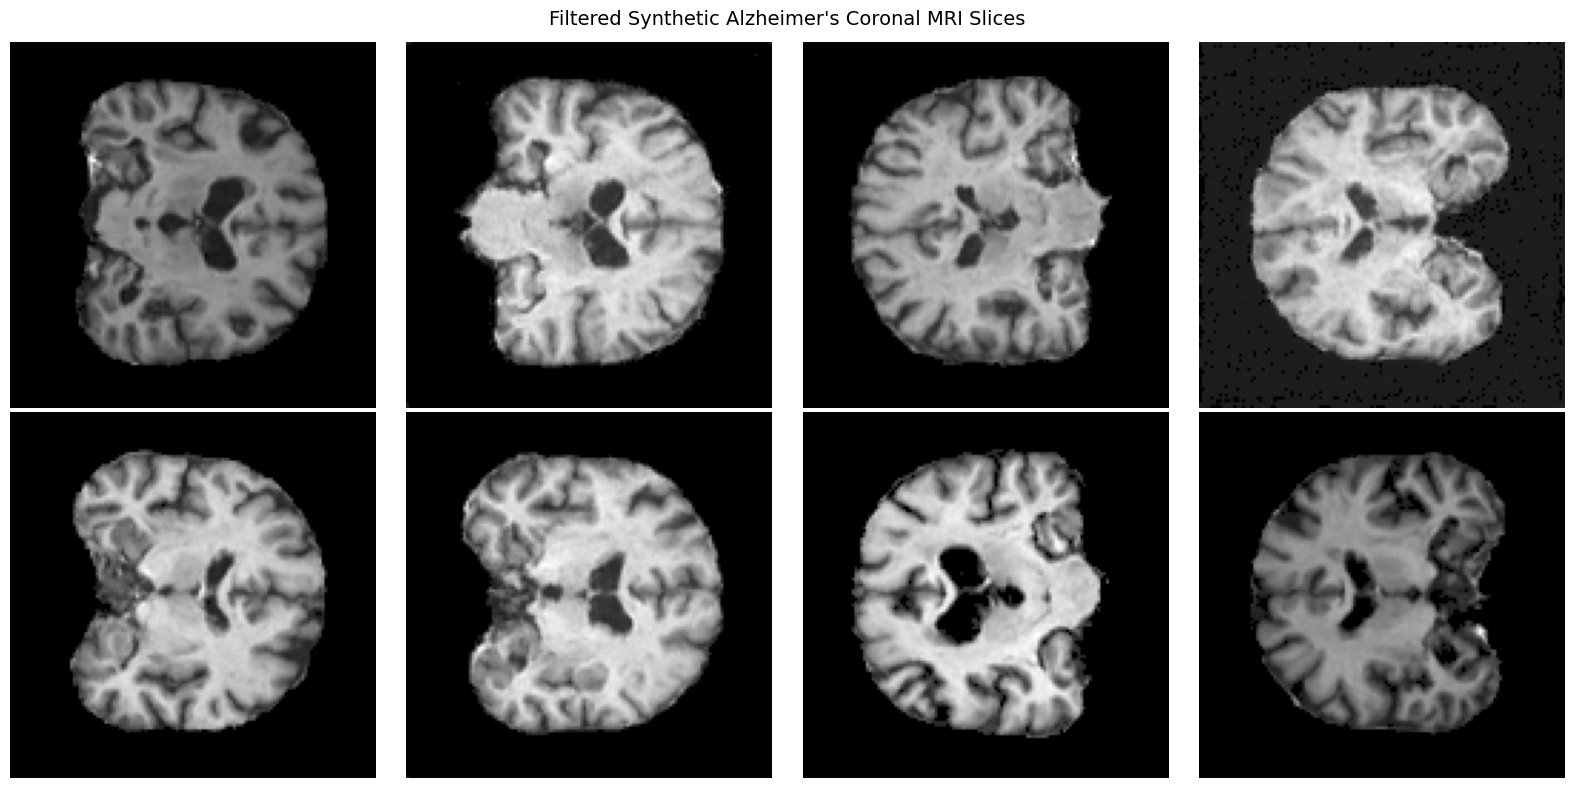

In [ ]:
# ──── GENERATING NEW SAMPLES WITH FILTER ────────────────────────────────────────
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as T
from diffusers import DDPMPipeline

# Image Filter fully improvised and enhanced by Claude AI -
# prompt: filter out images with haze or smoke background, low intensity images from generated synthetic outputs

# Helper Functions for Haze Detection and Post-Processing
# ---------------------------------------------------------
def clean_background(img_tensor, cutoff=0.08):
    """Zeros out residual low-intensity background noise/haze."""
    cleaned = img_tensor.clone()
    cleaned[cleaned < cutoff] = 0.0
    return cleaned

def is_hazy(img_tensor, corner_size=20, threshold=0.12):
    """
    Checks if outer background corners exceed an intensity threshold.
    Returns True if haze/smoke artifact is detected.
    """
    _, h, w = img_tensor.shape

    # Extract outer corners (where brain tissue shouldn't exist)
    top_left = img_tensor[:, :corner_size, :corner_size]
    top_right = img_tensor[:, :corner_size, -corner_size:]
    bottom_left = img_tensor[:, -corner_size:, :corner_size]
    bottom_right = img_tensor[:, -corner_size:, -corner_size:]

    max_corner_intensity = max([
        top_left.mean().item(),
        top_right.mean().item(),
        bottom_left.mean().item(),
        bottom_right.mean().item()
    ])

    return max_corner_intensity > threshold


# Main Generation Logic
# ---------------------------------------------------------
MODEL_PATH = '/content/drive/MyDrive/Dissertation2026/ddpm-coronal-v7_output/final_model'

print("Loading model...")
pipeline = DDPMPipeline.from_pretrained(MODEL_PATH).to('cuda')

TARGET_SAMPLES = 8
BATCH_SIZE = 8
clean_images = []
total_rejected = 0

print(f"Generating synthetic Alzheimer's coronal MRI slices (filtering out hazy images)...")

with torch.no_grad():
    while len(clean_images) < TARGET_SAMPLES:
        # Generate a batch
        raw_samples = pipeline(batch_size=BATCH_SIZE, num_inference_steps=1000).images

        for img in raw_samples:
            # Convert PIL Image to PyTorch Tensor [0, 1]
            img_tensor = T.ToTensor()(img)

            # 1. Clean lingering low-intensity background noise
            img_tensor = clean_background(img_tensor, cutoff=0.08)

            # 2. Reject if high haze is detected in the corners
            if not is_hazy(img_tensor, corner_size=20, threshold=0.12):
                # Convert back to PIL or display format
                clean_img_np = img_tensor.squeeze().cpu().numpy()
                clean_images.append(clean_img_np)

                if len(clean_images) == TARGET_SAMPLES:
                    break
            else:
                total_rejected += 1

print(f"\nSuccessfully generated {len(clean_images)} clean samples.")
print(f"Total rejected due to white haze: {total_rejected}")

# ---------------------------------------------------------
# Visualization
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Filtered Synthetic Alzheimer\'s Coronal MRI Slices', fontsize=14)

for i, img_np in enumerate(clean_images):
    row, col = i // 4, i % 4
    axes[row, col].imshow(img_np, cmap='gray')
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Dissertation2026/ddpm-coronal-v7_output/filtered_test_samples.png')
plt.show()

In [ ]:
#  ──── Checking for CORRELATION (real vs synthetic images) ────────────────────────────────────────

import numpy as np
from PIL import Image
import os

# Load a sample of real training images for comparison
real_dir = '/content/drive/MyDrive/Dissertation2026/oasis-coronal-alzheimers'
real_files = [f for f in os.listdir(real_dir) if f.endswith('.png')][:50]

real_images = []
for f in real_files:
    img = Image.open(os.path.join(real_dir, f)).convert('L').resize((128,128))
    real_images.append(np.array(img).flatten())
real_images = np.array(real_images)

# Compare each generated image to all real images using correlation
def max_correlation(gen_img, real_imgs):
    gen_flat = np.array(gen_img.convert('L').resize((128,128))).flatten()
    correlations = [np.corrcoef(gen_flat, r)[0,1] for r in real_imgs]
    return max(correlations)

print("Checking memorisation (correlation with real training data)...")
for i, img in enumerate(images):  # 'images' from your generation step
    max_corr = max_correlation(img, real_images)
    print(f"Sample {i+1}: max correlation = {max_corr:.3f}")

Checking memorisation (correlation with real training data)...
Sample 1: max correlation = 0.872
Sample 2: max correlation = 0.722
Sample 3: max correlation = 0.726
Sample 4: max correlation = 0.774
Sample 5: max correlation = 0.918
Sample 6: max correlation = 0.918
Sample 7: max correlation = 0.743
Sample 8: max correlation = 0.765


In [ ]:
# ─────────Generating 350 clean synthetic images from trained DDPM (using previous filter)───────────────── (6-8~ hours)
#──────────────────────────────────────────────────────────────────────────────────────────────────────────
"""Generating 350 images only due to resource constraints, instead class weights are used for compensating unbalanced data for classifiers"""
import torch
import os
import torchvision.transforms as T
from diffusers import DDPMPipeline
from PIL import Image

# Helper Functions
# ---------------------------------------------------------      # same filter from above used here for generating images
def clean_background(img_tensor, cutoff=0.08):
    """Zeros out residual low-intensity background noise/haze."""
    cleaned = img_tensor.clone()
    cleaned[cleaned < cutoff] = 0.0
    return cleaned

def is_hazy(img_tensor, corner_size=20, threshold=0.12):
    """
    Checks if outer background corners exceed an intensity threshold.
    Returns True if haze/smoke artifact is detected.
    """
    _, h, w = img_tensor.shape

    top_left = img_tensor[:, :corner_size, :corner_size]
    top_right = img_tensor[:, :corner_size, -corner_size:]
    bottom_left = img_tensor[:, -corner_size:, :corner_size]
    bottom_right = img_tensor[:, -corner_size:, -corner_size:]

    max_corner_intensity = max([
        top_left.mean().item(),
        top_right.mean().item(),
        bottom_left.mean().item(),
        bottom_right.mean().item()
    ])

    return max_corner_intensity > threshold

# Paths and Model Setup
# ---------------------------------------------------------
MODEL_PATH_V2  = '/content/drive/MyDrive/Dissertation2026/ddpm-coronal-v7_output/final_model'
GEN_DIR_V2_350 = '/content/drive/MyDrive/Dissertation2026/ddpm-coronal-v7_output/fid_generated_350_ddpm'
os.makedirs(GEN_DIR_V2_350, exist_ok=True)

pipeline = DDPMPipeline.from_pretrained(MODEL_PATH_V2).to('cuda')

target = 350
# Count only valid .png files in the folder to support session resumption
existing_files = [f for f in os.listdir(GEN_DIR_V2_350) if f.endswith('.png')]
count = len(existing_files)
total_rejected = 0

print(f"Already have {count} clean images. Generating up to {target} clean images...")

# Generation Loop with Filtering
# ---------------------------------------------------------
while count < target:
    # Generate in fixed batches of 16 (since some will be rejected)
    batch_size = 16

    with torch.no_grad():
        raw_samples = pipeline(batch_size=batch_size, num_inference_steps=1000).images

    for img in raw_samples:
        if count >= target:
            break

        # Convert PIL Image to [0, 1] Tensor for checking
        img_tensor = T.ToTensor()(img)

        # 1. Clean residual background haze
        img_tensor = clean_background(img_tensor, cutoff=0.08)

        # 2. Reject if haze is detected
        if not is_hazy(img_tensor, corner_size=20, threshold=0.12):
            # Convert back to PIL Image and save as RGB for FID tools
            clean_pil = T.ToPILImage()(img_tensor).convert('RGB')
            clean_pil.save(f'{GEN_DIR_V2_350}/gen_{count:03d}.png')
            count += 1
        else:
            total_rejected += 1

    print(f"Accepted: {count}/{target} | Total Filtered Out: {total_rejected}")

print(f"\nFinished! Saved {count} clean images in '{GEN_DIR_V2_350}'.")
print(f"Total hazy images rejected during run: {total_rejected}")

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

Already have 346 clean images. Generating up to 350 clean images...


  0%|          | 0/1000 [00:00<?, ?it/s]

Accepted: 350/350 | Total Filtered Out: 0

Finished! Saved 350 clean images in '/content/drive/MyDrive/Dissertation2026/ddpm-coronal-v7_output/fid_generated_350_ddpm'.
Total hazy images rejected during run: 0


In [ ]:
!pip install torch-fidelity -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 4.9 MB/s eta 0:00:00


In [ ]:
# ── Calculating FID: (IMAGENET FEATURE) ─────────────────────

# ── Step 1: FID: real vs real (equally splitting real alzheimer images) ────────────────────────────────────────
import os
import random
import shutil
from torch_fidelity import calculate_metrics

REAL_DIR = '/content/drive/MyDrive/Dissertation2026/oasis-coronal-alzheimers'
SPLIT_A  = '/content/drive/MyDrive/Dissertation2026/ddpm-coronal-v7_output/real_split_a'
SPLIT_B  = '/content/drive/MyDrive/Dissertation2026/ddpm-coronal-v7_output/real_split_b'

os.makedirs(SPLIT_A, exist_ok=True)
os.makedirs(SPLIT_B, exist_ok=True)

all_files = [f for f in os.listdir(REAL_DIR) if f.endswith('.png')]
random.shuffle(all_files)
# code partially enhanced by Claude Ai
half = len(all_files) // 2
files_a = all_files[:half]
files_b = all_files[half:half*2]

for f in files_a:
    shutil.copy(os.path.join(REAL_DIR, f), os.path.join(SPLIT_A, f))
for f in files_b:
    shutil.copy(os.path.join(REAL_DIR, f), os.path.join(SPLIT_B, f))

print(f"Split A: {len(files_a)} images")
print(f"Split B: {len(files_b)} images")

print("\nCalculating Real-vs-Real baseline FID...")
metrics = calculate_metrics(
    input1=SPLIT_A,
    input2=SPLIT_B,
    cuda=True,
    fid=True,
    verbose=False
)
print(f"\nReal-vs-Real Baseline FID: {metrics['frechet_inception_distance']:.2f}")

Split A: 350 images
Split B: 350 images

Calculating Real-vs-Real baseline FID...

Real-vs-Real Baseline FID: 5.40


In [ ]:
# ── Step 2: FID: Generated vs Real  (reuses existing 350-image real split from before) ──
!pip install torch-fidelity -q

import torch
import os
from torch_fidelity import calculate_metrics

metrics = calculate_metrics(
    input1=GEN_DIR_V2_350,
    input2='/content/drive/MyDrive/Dissertation2026/ddpm-coronal-v7_output/real_split_a',  # same 350 real images as Run 1's fair test
    cuda=True, fid=True, verbose=False
)
print(f"Run 2 FID (350 vs 350, fair comparison): {metrics['frechet_inception_distance']:.2f}")

Run 2 FID (350 vs 350, fair comparison): 87.39


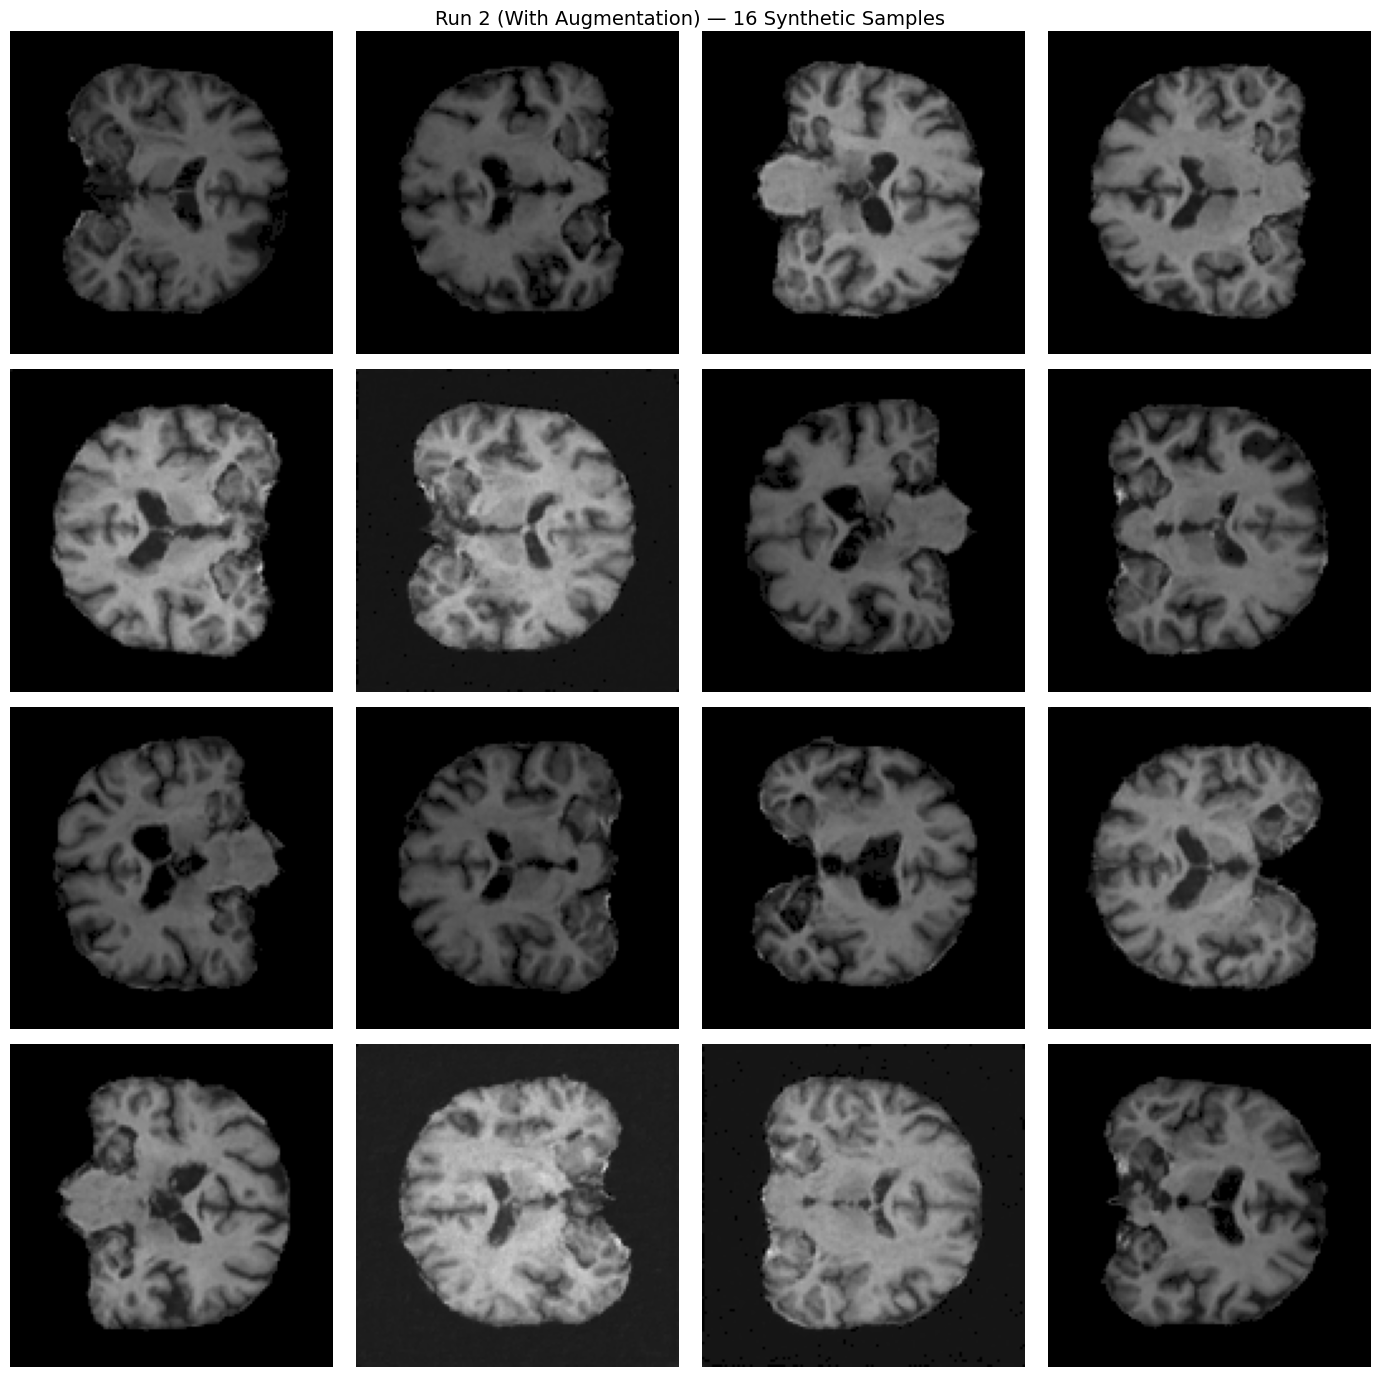

In [ ]:
# ── Step 3: Visual check — 16-image grid, this time checking ventricle diversity ──
import matplotlib.pyplot as plt
from PIL import Image

GEN_DIR_V2_350 = '/content/drive/MyDrive/Dissertation2026/ddpm-coronal-v7_output/fid_generated_350_ddpm'
files = sorted(os.listdir(GEN_DIR_V2_350))[:16]
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle('Run 2 (With Augmentation) — 16 Synthetic Samples', fontsize=14)
for i, f in enumerate(files):
    img = Image.open(os.path.join(GEN_DIR_V2_350, f))
    axes[i//4, i%4].imshow(img, cmap='gray')
    axes[i//4, i%4].axis('off')
plt.tight_layout()
plt.show()